In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = pd.read_csv("AAPL_stock_2015_2025.csv")

In [3]:
print("Dataset Preview:")
display(data.head())

Dataset Preview:


,Date,Close,High,Low,Open,Volume
0,NaN,AAPL,AAPL,AAPL,AAPL,AAPL
1,2015-01-02,24.261043548583984,24.729266505118662,23.82166783410134,24.718170500399545,212818400
2,2015-01-05,23.57757568359375,24.11015184940222,23.39117495671791,24.030265339880305,257142000
3,2015-01-06,23.57979393005371,23.83942422525078,23.218085117057225,23.641927502270494,263188400
4,2015-01-07,23.910436630249023,24.01029392504949,23.67743401836389,23.788387320592424,160423600


In [4]:
print("\nColumn Names:")
print(data.columns)


Column Names:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [5]:
data["Date"] = pd.to_datetime(data["Date"])

In [6]:
data = data.sort_values("Date")

In [8]:
data["Close"] = pd.to_numeric(data["Close"], errors="coerce")
data = data.dropna(subset=["Close"]).copy()

In [9]:
print(data["Close"].dtype)
print(data[["Date", "Close"]].head())

float64
        Date      Close
1 2015-01-02  24.261044
2 2015-01-05  23.577576
3 2015-01-06  23.579794
4 2015-01-07  23.910437
5 2015-01-08  24.829130


In [10]:
data["MA_5"] = data["Close"].rolling(5).mean()
data["MA_10"] = data["Close"].rolling(10).mean()

In [11]:
data["Tomorrow_Close"] = data["Close"].shift(-1)

In [12]:
data = data.dropna()

In [13]:
features = ["Open", "High", "Low", "Close", "Volume", "MA_5", "MA_10"]
X = data[features]
y = data["Tomorrow_Close"]

In [14]:
split_index = int(len(data) * 0.80)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (2004, 7)
Testing data: (502, 7)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
predictions = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\nModel Performance")
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))


Model Performance
Mean Absolute Error: 1.91
Root Mean Squared Error: 2.58


In [19]:
results = pd.DataFrame({
    "Date": data["Date"].iloc[split_index:],
    "Actual Price": y_test,
    "Predicted Price": predictions
})

print("\nActual vs Predicted Prices:")


Actual vs Predicted Prices:


In [20]:
display(results.head(10))

,Date,Actual Price,Predicted Price
2014,2022-12-30,123.330650,127.896093
2015,2023-01-03,124.602722,122.754213
2016,2023-01-04,123.281342,124.788869
2017,2023-01-05,127.817360,123.482512
2018,2023-01-06,128.339966,127.434680
2019,2023-01-09,128.911911,129.015897
2020,2023-01-10,131.633560,128.138024
2021,2023-01-11,131.554672,131.212131
2022,2023-01-12,132.885880,130.840813
2023,2023-01-13,134.049515,132.834010


In [21]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

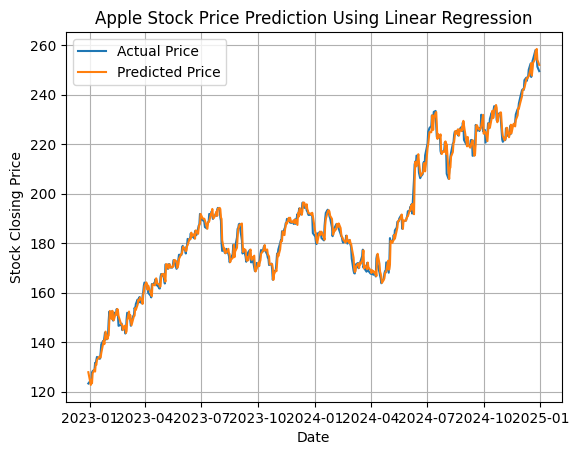

In [22]:
plt.plot(results["Date"], results["Actual Price"], label="Actual Price")
plt.plot(results["Date"], results["Predicted Price"], label="Predicted Price")

plt.title("Apple Stock Price Prediction Using Linear Regression")
plt.xlabel("Date")
plt.ylabel("Stock Closing Price")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
latest_data = data[features].tail(1)

next_day_prediction = model.predict(latest_data)

print(
    "\nPredicted next-day closing price:",
    round(next_day_prediction[0], 2)
)


Predicted next-day closing price: 252.05
